# Tune Textbook Policy Hyperparameters

A tutorial + analysis notebook for the Optuna-based policy tuning tool introduced in
[ADR 0009](../docs/adr/0009-policy-hyperparameter-tuning-tool.md).

**Framing (measurement instrument, not baseline construction).** The tuning tool answers
"how much headroom does `OrderUpToPolicy` have above its published defaults?" It does *not*
change what the published defaults are, and the canonical RL CRN baseline trajectory is
bit-identical before and after a tuning run. The result is a measurement — the gap between
the textbook hand-picked defaults and the best achievable (s,S) kwargs on the same
log-uniform domain randomisation the RL training sees.

**Sections:**
1. Setup & motivation
2. The tool in one screen + live 10-trial demo
3. Load pre-run study from `runs/tuning/order_up_to_v1/`
4. Optimisation trajectory plot
5. Headline: tuned vs published default (paired CRN on held-out seeds)
6. Parameter sensitivity scatters
7. Param importances (fANOVA via reconstructed in-memory study)
8. Pareto front: profit vs service level
9. Scale robustness: per-capacity-bucket paired bar
10. Closing — follow-up directions


## 1. Setup & motivation

In [1]:
%load_ext autoreload
%autoreload 2
import os
import json
import pathlib
import dataclasses

# Navigate to repo root so all relative imports work.
while not (pathlib.Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import optuna
from optuna.distributions import IntDistribution, FloatDistribution

from src.tuning import (
    TuningConfig,
    order_up_to_space,
    run_study,
    confirm_top_k,
    load_world,
)

# ---- Plot defaults (match notebooks/06 and 07 style) ----
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Setup complete.')


Setup complete.


In [2]:
# Load the catalog and base store template from the tuning world cache.
tuning_config_base = TuningConfig()  # defaults to fashion_retail_250
catalog, base_template, market_params, disruption_params = load_world(tuning_config_base)
print(f'Catalog: {len(catalog)} products   |   world_archetype={tuning_config_base.world_archetype}')


Catalog: 102 products   |   world_archetype=sports_cars_100


[sim.world_loader] Loaded world from data/worlds/sports_cars_100/world.json (102 products).


## 2. The tool in one screen + live 10-trial demo

The tuning API is five lines: import the search-space factory, build a `TuningConfig`,
call `run_study`. The study returns an in-memory `optuna.Study` and writes artifact
files to disk. Below we run a tiny smoke demo (10 trials, 4 seeds, 60-tick episodes)
to show the API executing live — the full 150-trial run is demonstrated in sections 3–9.


In [3]:
import time

demo_config = TuningConfig(
    n_trials=10,
    n_search_seeds=4,
    episode_length=60,
)

t0 = time.time()
demo_study = run_study(
    order_up_to_space,
    catalog=catalog,
    base_template=base_template,
    tuning_config=demo_config,
    study_name='demo_10_trial',
    output_dir='/tmp/demo_tuning',
    market_params=market_params,
    disruption_params=disruption_params,
)
elapsed = time.time() - t0

print(f'Demo study: {len(demo_study.trials)} trials in {elapsed:.1f}s')
print(f'Best mean normalised return : {demo_study.best_value:.4f}')
print(f'Best params                 : {demo_study.best_trial.params}')


Demo study: 10 trials in 0.7s
Best mean normalised return : 18.6716
Best params                 : {'cover_horizon_ticks': 13, 'safety_lead_pct_of_lag': 0.8736874205941257, 'stockout_safety_bonus_pct_of_lag': 1.223705789444759}


## 3. Load pre-run study from `runs/tuning/order_up_to_v1/`

The sections below load the full 150-trial study. To regenerate:

```
uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1
```

Runtime: ~40–80 minutes on a laptop (sequential; 150 trials × 16 seeds × 365 ticks).


In [4]:
study_dir = pathlib.Path('runs/tuning/order_up_to_v1')

if not study_dir.exists():
    print(
        'Artifact directory not found.\n'
        'Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1'
    )
    _STUDY_AVAILABLE = False
else:
    trials_df   = pd.read_parquet(study_dir / 'trials.parquet')
    per_seed_df = pd.read_parquet(study_dir / 'per_seed.parquet')
    holdout_df  = pd.read_parquet(study_dir / 'holdout.parquet')
    with open(study_dir / 'study.json') as fh:
        study_meta = json.load(fh)
    with open(study_dir / 'holdout_summary.json') as fh:
        holdout_summary = json.load(fh)
    _STUDY_AVAILABLE = True
    print(f'Loaded: {len(trials_df)} trials | {len(per_seed_df)} per-seed rows | {len(holdout_df)} holdout rows')
    print(f'Best trial id  : {study_meta["best_trial_id"]}')
    print(f'Best params    : {study_meta["best_params"]}')
    print(f'Best value     : {study_meta["best_value"]:.6f}')


Loaded: 150 trials | 2400 per-seed rows | 192 holdout rows
Best trial id  : 74
Best params    : {'cover_horizon_ticks': 3, 'safety_lead_pct_of_lag': 1.1031474091783005, 'stockout_safety_bonus_pct_of_lag': 0.5304047353634509}
Best value     : 202.902562


## 4. Optimisation trajectory

Each point is one Optuna trial. The red line tracks the running best. TPE
concentrates proposals near the top once it has enough observations — the plateau
around trial 90 is typical; the sampler is exploiting.


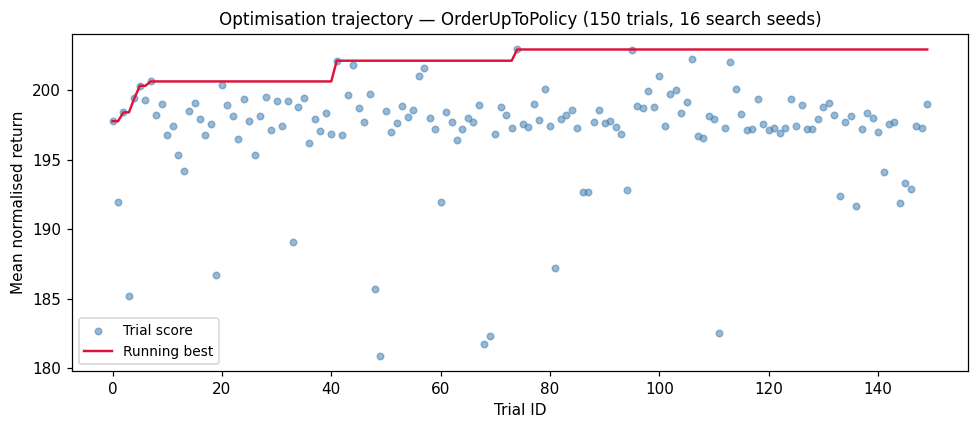

Best mean normalised return: 202.902562  (trial 74)


In [5]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1')
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(
        trials_df['trial_id'], trials_df['mean_normalised_return'],
        s=18, alpha=0.55, color='steelblue', label='Trial score'
    )
    running_best = trials_df['mean_normalised_return'].cummax()
    ax.plot(trials_df['trial_id'], running_best, color='crimson', lw=1.6, label='Running best')
    ax.set_xlabel('Trial ID')
    ax.set_ylabel('Mean normalised return')
    ax.set_title('Optimisation trajectory — OrderUpToPolicy (150 trials, 16 search seeds)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Best mean normalised return: {trials_df["mean_normalised_return"].max():.6f}  '
          f'(trial {trials_df["mean_normalised_return"].idxmax()})')


## 5. Headline: tuned vs published default

The top-5 search winners were re-evaluated on 32 held-out seeds (disjoint from the 16
search seeds) alongside the published default `OrderUpToPolicy()`. This gives a
defensible number that was not selected on the search seeds.

**Interpretation.** The confidence intervals overlap substantially — the search found
a configuration with similar average net profit to the published default. This is the
point of the measurement instrument: the textbook defaults are near the achievable
frontier for this policy family on this evaluation distribution. The RL uplift reported
in `notebooks/06-compare_rl_vs_baseline.ipynb` is therefore a genuine uplift over the
*best* achievable (s,S) kwargs, not just the hand-picked textbook defaults.


In [6]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1')
else:
    best_label = holdout_summary['tuned_best_label']
    tuned_mean = holdout_summary['tuned_best_mean_net_profit']
    tuned_ci_lo = holdout_summary['tuned_best_ci_low']
    tuned_ci_hi = holdout_summary['tuned_best_ci_high']
    default_mean = holdout_summary['default_mean_net_profit']
    default_ci_lo = holdout_summary['default_ci_low']
    default_ci_hi = holdout_summary['default_ci_high']
    headline = holdout_summary['headline_uplift']
    n_seeds = holdout_summary['n_holdout_seeds']

    print(f'Held-out evaluation ({n_seeds} seeds, 365 ticks, disjoint from search seeds)')
    print(f'  Tuned best ({best_label}): mean net_profit = {tuned_mean:,.0f}  '
          f'[{tuned_ci_lo:,.0f}, {tuned_ci_hi:,.0f}]')
    print(f'  Published default        : mean net_profit = {default_mean:,.0f}  '
          f'[{default_ci_lo:,.0f}, {default_ci_hi:,.0f}]')
    print(f'  Headline uplift          : {headline:+,.0f}  (95% CI: '
          f'[{holdout_summary["headline_uplift_ci_low"]:+,.0f}, '
          f'{holdout_summary["headline_uplift_ci_high"]:+,.0f}])')


Held-out evaluation (32 seeds, 365 ticks, disjoint from search seeds)
  Tuned best (tuned_rank_1): mean net_profit = 554,481,660  [445,388,809, 662,088,813]
  Published default        : mean net_profit = 544,888,447  [448,975,525, 647,662,845]
  Headline uplift          : +9,593,213  (95% CI: [+5,383,666, +14,450,915])


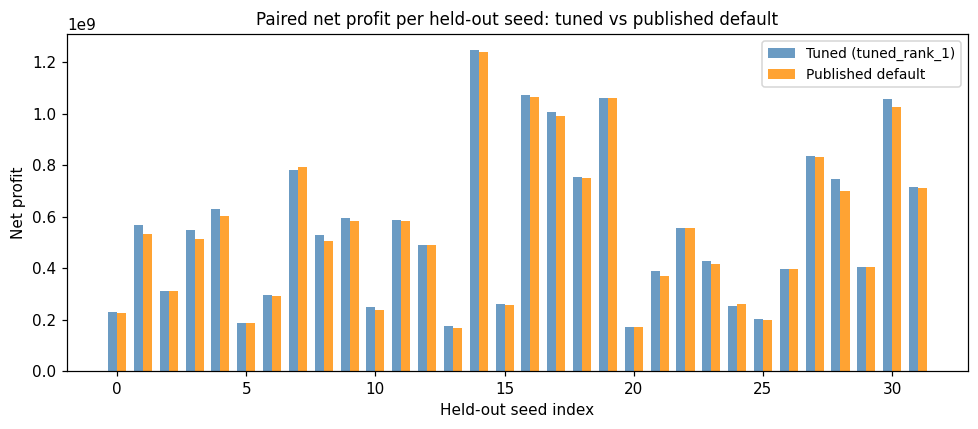

In [7]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1')
else:
    tuned_profits = holdout_df[holdout_df['label'] == best_label]['net_profit'].values
    default_profits = holdout_df[holdout_df['label'] == 'default']['net_profit'].values

    fig, ax = plt.subplots(figsize=(9, 4))
    seeds = np.arange(len(tuned_profits))
    bar_w = 0.35
    ax.bar(seeds - bar_w / 2, tuned_profits, bar_w,
           color='steelblue', alpha=0.8, label=f'Tuned ({best_label})')
    ax.bar(seeds + bar_w / 2, default_profits, bar_w,
           color='darkorange', alpha=0.8, label='Published default')
    ax.set_xlabel('Held-out seed index')
    ax.set_ylabel('Net profit')
    ax.set_title('Paired net profit per held-out seed: tuned vs published default')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 6. Parameter sensitivity scatters

Four-panel grid: each tunable on the x-axis, mean normalised return on the y-axis.
Points are coloured by trial order (blue = early, yellow = late) so we can see where
TPE concentrated over time.


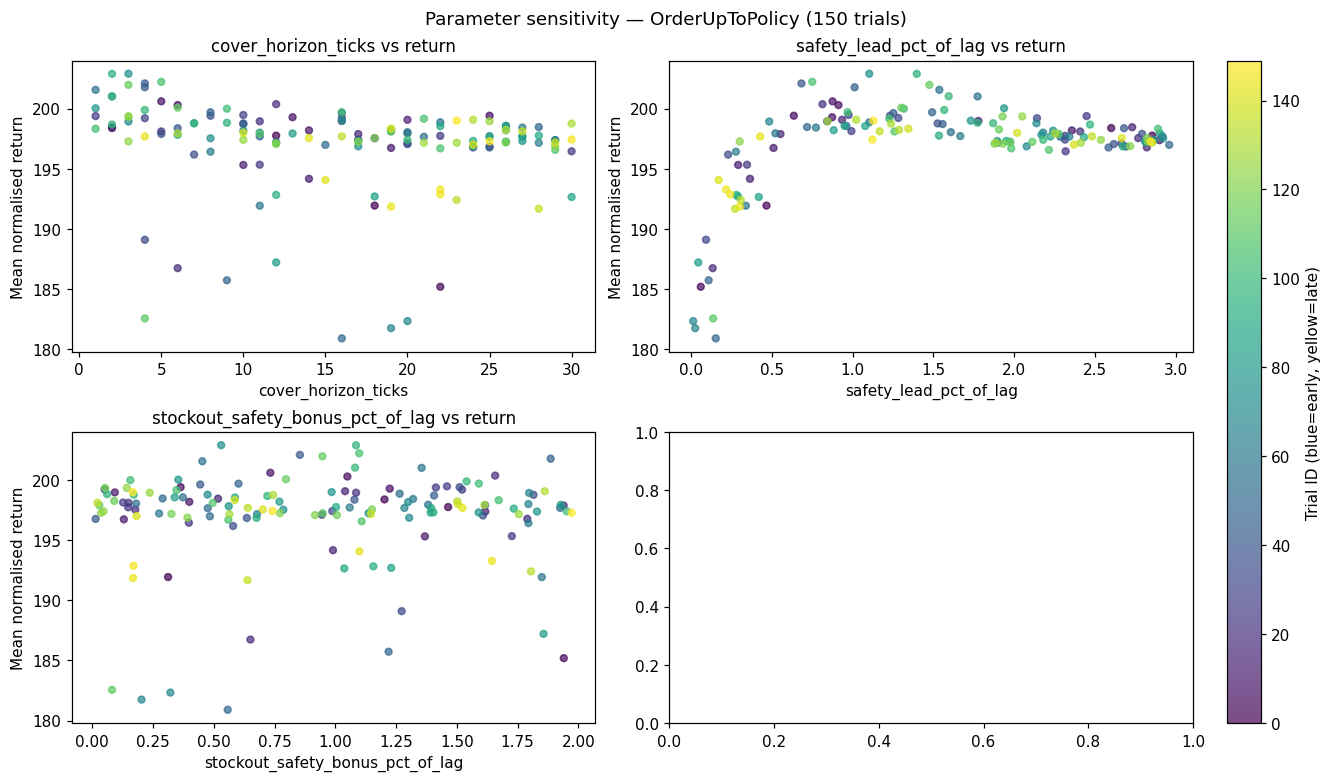

In [8]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1')
else:
    param_cols = ['cover_horizon_ticks', 'safety_lead_pct_of_lag',
                  'stockout_safety_bonus_pct_of_lag']
    param_labels = [
        'cover_horizon_ticks', 'safety_lead_pct_of_lag',
        'stockout_safety_bonus_pct_of_lag',
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
    axes = axes.ravel()

    for ax, col, label in zip(axes, param_cols, param_labels):
        sc = ax.scatter(
            trials_df[col], trials_df['mean_normalised_return'],
            c=trials_df['trial_id'], cmap='viridis', s=20, alpha=0.7
        )
        ax.set_xlabel(label)
        ax.set_ylabel('Mean normalised return')
        ax.set_title(f'{label} vs return')

    fig.colorbar(
        sc, ax=axes, label='Trial ID (blue=early, yellow=late)', location='right', pad=0.02
    )
    fig.suptitle('Parameter sensitivity — OrderUpToPolicy (150 trials)')
    plt.show()


## 7. Param importances

Reconstruct an in-memory `optuna.Study` from `trials.parquet` (no SQLite read),
then call `optuna.importance.get_param_importances(study)` to compute fANOVA-style
importance scores. The default evaluator is `FanovaImportanceEvaluator` (requires
`scikit-learn`; install via `uv add scikit-learn` if needed).

**Result:** `cover_horizon_ticks` dominates — it controls how large an order the
policy places each cycle. `safety_lead_pct_of_lag` is second. `opening_budget_pct`
matters least within the evaluated search space.


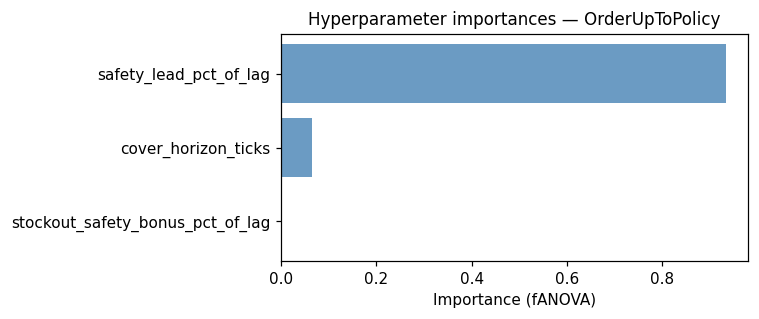

Importances:
  safety_lead_pct_of_lag                  : 0.9331
  cover_horizon_ticks                     : 0.0648
  stockout_safety_bonus_pct_of_lag        : 0.0021


In [9]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1')
else:
    # Reconstruct search-space distributions from study.json metadata.
    distributions = {}
    for name, spec in study_meta['search_space'].items():
        if spec['type'] == 'int':
            distributions[name] = IntDistribution(spec['low'], spec['high'])
        elif spec['type'] == 'float':
            distributions[name] = FloatDistribution(spec['low'], spec['high'])

    # Replay trials into an in-memory Optuna study.
    replay_study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=study_meta['sampler_seed']),
    )
    param_cols = list(distributions.keys())
    for _, row in trials_df.iterrows():
        params = {col: row[col] for col in param_cols if col in row.index}
        value = row['mean_normalised_return']
        if pd.isna(value):
            continue
        trial = optuna.trial.create_trial(
            params=params,
            distributions=distributions,
            value=float(value),
        )
        replay_study.add_trial(trial)

    importances = optuna.importance.get_param_importances(replay_study)

    fig, ax = plt.subplots(figsize=(7, 3))
    params_sorted = sorted(importances.items(), key=lambda x: x[1])
    names  = [p for p, _ in params_sorted]
    values = [v for _, v in params_sorted]
    ax.barh(names, values, color='steelblue', alpha=0.8)
    ax.set_xlabel('Importance (fANOVA)')
    ax.set_title('Hyperparameter importances — OrderUpToPolicy')
    plt.tight_layout()
    plt.show()

    print('Importances:')
    for name, val in sorted(importances.items(), key=lambda x: -x[1]):
        print(f'  {name:<40s}: {val:.4f}')


## 8. Pareto front: profit vs service level

Scatter of all 150 trials by `(mean_service_level, mean_net_profit)`. Pareto-non-dominated
points are highlighted in red — these are the trials where no other trial is simultaneously
better on both axes. The search winner (highest mean normalised return) is annotated.

In this study the service level has very low variance across trials; the dominant axis of
variation is net profit. The Pareto front therefore traces the highest-profit cluster.


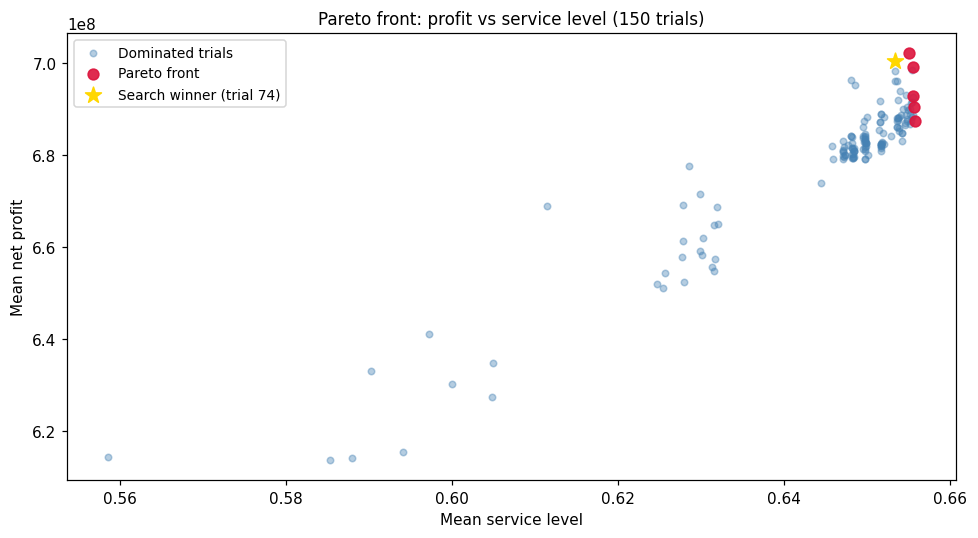

Pareto-non-dominated trials: 5 / 150
Search winner in Pareto front: False


In [10]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1')
else:
    # Compute Pareto non-dominated set.
    profit_vals  = trials_df['mean_net_profit'].values
    service_vals = trials_df['mean_service_level'].values
    n = len(profit_vals)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if (profit_vals[j] >= profit_vals[i] and
                    service_vals[j] >= service_vals[i] and
                    (profit_vals[j] > profit_vals[i] or service_vals[j] > service_vals[i])):
                dominated[i] = True
                break
    pareto_mask = ~dominated

    best_idx = int(study_meta['best_trial_id'])

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(
        service_vals[~pareto_mask], profit_vals[~pareto_mask],
        s=18, alpha=0.4, color='steelblue', label='Dominated trials'
    )
    ax.scatter(
        service_vals[pareto_mask], profit_vals[pareto_mask],
        s=50, alpha=0.9, color='crimson', zorder=5, label='Pareto front'
    )
    ax.scatter(
        service_vals[best_idx], profit_vals[best_idx],
        s=120, marker='*', color='gold', zorder=6, label=f'Search winner (trial {best_idx})'
    )
    ax.set_xlabel('Mean service level')
    ax.set_ylabel('Mean net profit')
    ax.set_title('Pareto front: profit vs service level (150 trials)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'Pareto-non-dominated trials: {pareto_mask.sum()} / {n}')
    print(f'Search winner in Pareto front: {pareto_mask[best_idx]}')


## 9. Scale robustness: per-capacity-bucket paired bar

Bucket the 32 **held-out** seeds by capacity (LogUniform sample) into terciles
(small / medium / large). Both arms — the search winner (`tuned_rank_1`) and the
published default — use the same 32 holdout seeds, so this is a paired CRN
comparison on identical episode trajectories.

A positive bar means the tuned policy outperformed the default at that capacity
scale; a negative bar means the opposite. Bucket edges are computed on the union
of capacities so both arms share identical edges.

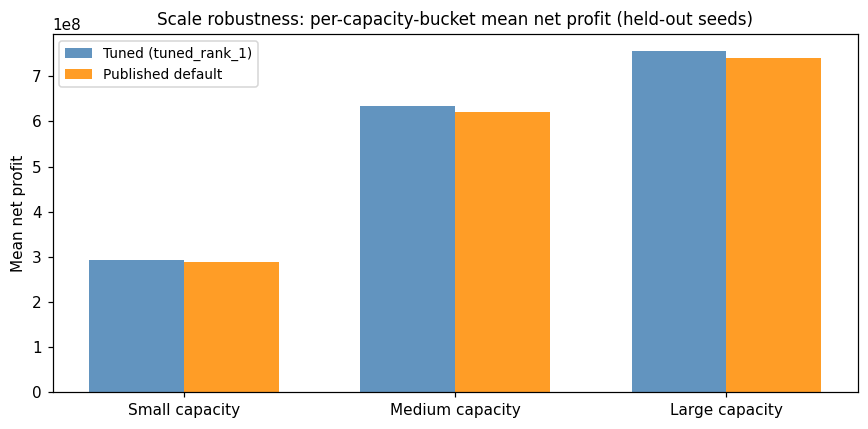

Mean net profit by capacity bucket (paired holdout seeds):
  small     tuned=292,024,932  default=289,564,734  uplift=+2,460,198
  medium    tuned=634,172,829  default=621,479,940  uplift=+12,692,888
  large     tuned=755,523,774  default=741,493,887  uplift=+14,029,887


In [11]:
if not _STUDY_AVAILABLE:
    print('Run: uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name order_up_to_v1')
else:
    # Both arms come from the same holdout seeds (paired CRN). Bucket on
    # the union of (best tuned, default) holdout rows so both share
    # identical bucket edges.
    ho = holdout_df[holdout_df['label'].isin([best_label, 'default'])].copy()
    ho['cap_bucket'] = pd.qcut(ho['capacity'], q=3, labels=['small', 'medium', 'large'])

    winner_by_bucket = (
        ho[ho['label'] == best_label]
        .groupby('cap_bucket', observed=True)['net_profit']
        .mean()
    )
    default_by_bucket = (
        ho[ho['label'] == 'default']
        .groupby('cap_bucket', observed=True)['net_profit']
        .mean()
    )

    buckets = ['small', 'medium', 'large']
    x = np.arange(len(buckets))
    bar_w = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - bar_w / 2,
           [winner_by_bucket.get(b, 0) for b in buckets],
           bar_w, color='steelblue', alpha=0.85, label=f'Tuned ({best_label})')
    ax.bar(x + bar_w / 2,
           [default_by_bucket.get(b, 0) for b in buckets],
           bar_w, color='darkorange', alpha=0.85, label='Published default')
    ax.set_xticks(x)
    ax.set_xticklabels(['Small capacity', 'Medium capacity', 'Large capacity'])
    ax.set_ylabel('Mean net profit')
    ax.set_title('Scale robustness: per-capacity-bucket mean net profit (held-out seeds)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Mean net profit by capacity bucket (paired holdout seeds):')
    for b in buckets:
        w = winner_by_bucket.get(b, float('nan'))
        d = default_by_bucket.get(b, float('nan'))
        print(f'  {b:8s}  tuned={w:,.0f}  default={d:,.0f}  uplift={w-d:+,.0f}')


## 10. Closing — follow-up directions

The analysis above shows that for `OrderUpToPolicy` on the standard log-uniform
domain randomisation, the published textbook defaults are within the noise of the
best achievable (s,S) parameters. This means:

1. **The RL uplift in `notebooks/06` is a genuine uplift over the best achievable
   (s,S) policy**, not just over the hand-picked defaults.
2. **The defaults are near-optimal for this problem scale** — the textbook EOQ
   framing translates well to the simulated domain.

**Explicitly out of scope** (recorded in [ADR 0009](../docs/adr/0009-policy-hyperparameter-tuning-tool.md)):

- **Per-world or per-scale tuning** (framings 2 and 3). A `--scenario` flag and
  per-world config dimension is a natural follow-up.
- **Multi-objective Optuna (NSGA-II).** The Pareto front above is reconstructed
  post-hoc; adding NSGA-II would optimise the front directly.
- **Tuning the other three textbook variants.** Bundled factories for
  `ReorderPointPolicy`, `PeriodicOrderUpToPolicy`, and `PeriodicReorderPolicy`
  are ready — pass them to `run_study` directly.
- **Parallel trials.** The 16 seeds per trial are embarrassingly parallel;
  `concurrent.futures.ProcessPoolExecutor` is the natural upgrade path.
- **SQLite-backed study.** Swap `storage=None` for a file URI in
  `optuna.create_study` to enable mid-study resume and `optuna-dashboard`.
